# Analisis de Estimulos Revision

Modificado JUnio 2025

In [1]:
%pip install numpy scipy matplotlib cycler

Note: you may need to restart the kernel to use updated packages.


In [45]:
import numpy as np
from scipy import signal, fft
from scipy.io import wavfile
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler # Import cycler
import matplotlib.font_manager as fm
plt.style.use('default')

In [46]:
%pip install git+https://github.com/meguia/IRma.git
%pip install pyyaml sounddevice

  Cloning https://github.com/meguia/IRma.git to c:\users\lucas\appdata\local\temp\pip-req-build-w1q7_bbi
  Resolved https://github.com/meguia/IRma.git to commit 98808225c89da48bb19466a83b0cb0976f95d417
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/meguia/IRma.git 'C:\Users\Lucas\AppData\Local\Temp\pip-req-build-w1q7_bbi'


Note: you may need to restart the kernel to use updated packages.


In [3]:
from irma.acoustics import *
from irma.process import make_filterbank
from irma.room import paracoustic
from irma.display import *

In [8]:
fs = 96000
dt = 1/fs
N = fs*20
rpath = "./" # copiar del path de Drive a la izquierda

In [9]:
dist = np.array([1.5, 2, 2.5, 3.3, 4.3, 5.6, 7.2, 9.4, 12, 15.5, 20, 26])
dists = ['1.5', '2', '2.5', '3.3', '4.3', '5.6', '7.2', '9.4', '12', '15.5', '20', '26']

In [10]:
fb0 = make_filterbank(fmin=31.25,noct=10,bwoct=1,fs=fs,order=1,N=10000,bankname='fbank_octave',show=True)

Filter bank generated: 10 octaves,1 bands/octave,from 31.25 Hz,Stored in file fbank_octave


In [11]:

ir_binaural_all = np.load(rpath + "ir_binaural_all.npy")

In [12]:
np.arange(1,11)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [13]:
pard = np.zeros((12,12))
for n in np.arange(12): 
    par = paracoustic(ir_binaural_all[n,:,0], method='RT20', bankname='fbank_octave', tmax=15.0, fs_default=96000)
    pard[n,:] = par['RT20'].flatten()

Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000
Using sample rate from filter bank:96000


In [14]:
pard

array([[28.36481496, 25.00270959, 14.77490216, 10.70805015,  7.42130365,
         4.71842649,  2.79830051,  1.56157546,  0.94700415,  0.35558199,
         2.20911068,  4.24145798],
       [30.86876196, 25.74140598, 15.4317498 , 11.17872693,  7.57399689,
         4.76158528,  2.90035769,  1.99781342,  1.0959647 ,  0.41562021,
         2.66130787,  5.33800405],
       [32.34270349, 27.93642894, 15.68808981, 11.08334613,  7.61452093,
         5.02123101,  3.04562467,  2.23484663,  1.09799779,  0.47596135,
         2.87437544,  6.14801521],
       [32.47077416, 29.51257947, 16.09144129, 11.53334625,  7.78277173,
         4.99419835,  3.30410405,  2.47578545,  1.2065691 ,  0.64719664,
         3.13349748,  7.71395692],
       [33.54020261, 28.90348719, 15.63105616, 11.4773988 ,  7.87091816,
         5.27523983,  3.51421242,  2.87501148,  1.42585663,  0.83630426,
         3.39137751,  8.66091221],
       [33.19145995, 27.82748676, 15.88390653, 11.6844607 ,  8.09927198,
         5.19775013,  

In [15]:
np.nanmean(pard[:9,:],axis=0)

array([32.05696783, 27.90201786, 15.98408629, 11.42327633,  7.87756132,
        5.13365514,  3.37215758,  2.5955408 ,  1.42636187,  0.74153227,
        3.24285205,  7.9969903 ])

In [17]:
# cargamops los valores de ncross
ncross = np.load(rpath + "drcross.npy")

# Funciones de Conveniencia para pasar luego a acousticfields

*   List item
*   List item



In [18]:
def fadeinout(data, fadein=0.05, fadeout=None, fs=48000):
    if fadein is not None:
        nin = int(fadein*fs)
        a = (1.0-np.cos(np.linspace(0,np.pi,nin)))/2.0 
        if data.ndim == 2:
            for n in range(data.shape[1]):
                data[:nin,n]  *= a
        else:
            data[:nin] *= a
    if fadeout is not None:
        nout = int(fadeout*fs)
        a = (1.0+np.cos(np.linspace(0,np.pi,nout)))/2.0 
        if data.ndim == 2:
            for n in range(data.shape[1]):
                data[-nout:,n]  *= a
        else:
            data[-nout:] *= a        
    return

In [19]:
def whitenoise(T, flow=None, fhigh=None, fslow=None, fshigh=None, nchannels=1, fadein=None, fadeout=None, fs=48000, filename="wnoise"):
    """
    Genera ruido blanco de duracion T limitado en banda entre flow y fhigh (fslow y fshigh dan las pendientes de
    la sigmoidea del limite de banda) puede generar nchannels canales
    """
    nsamples = int(fs*T)
    freqs = np.fft.rfftfreq(nsamples, 1/fs)
    freqs[0] = 1/nsamples
    fmax = freqs[-1]
    if flow is not None:
        if fslow is None:
            fslow=flow
        s1 = sigmoid(freqs/fmax,flow/fmax,fslow/fmax)
    else:
        s1 = 1
    if fhigh is not None:
        if fshigh is None:
            fshigh=fhigh/4.0
        s2 = sigmoid(freqs/fmax,fhigh/fmax,-fshigh/fmax)
    else:
        s2 = 1
    real = s1*s2*np.random.randn(nchannels, freqs.shape[0])
    imag = s1*s2*np.random.randn(nchannels, freqs.shape[0])
    if not nsamples & 1:
        imag[-1] = 0.
    wnoise = np.array(np.fft.irfft(real + 1j*imag),ndmin=2, dtype='float64').T
    wnoise /= np.abs(wnoise).max(axis=0)
    fadeinout(wnoise, fadein=fadein, fadeout=fadeout, fs=fs)
    wavfile.write(filename + '.wav',fs,wnoise) 
    return wnoise

In [20]:
def find_dir(data, pw=1.0, fs=48000):
    """ Multichannel
    """
    nw = int(np.floor(pw*fs/1000))
    if data.ndim == 1:
        data = data[:,np.newaxis] # el array debe ser 2D
    _, nchan = np.shape(data)
    ndir = np.zeros((3,nchan),dtype=int)
    # find first local maximum 20 dB below the absolute maximum value
    for n in range(nchan):
        pmax = np.max(np.abs(data[:,n]))
        n0 = np.argmax(data[:,n]>pmax/10)
        n0=max(n0,nw+1)
        npk = np.argmax(np.abs(data[n0-nw:n0+nw,n]))
        nc = n0+npk-nw-2
        ndir[0,n] = np.maximum(1,int(nc-1.0*nw))
        ndir[1,n] = int(nc+1.5*nw)
        ndir[2,n] = nc
    return ndir

In [21]:
def fast_ccf(x1,x2):
    wav_len = x1.shape[0]
    wf = np.hanning(wav_len)
    x1 = x1*wf
    x2 = x2*wf
    X1 = np.fft.fft(x1,2*wav_len-1)# equivalent to add zeros
    X2 = np.fft.fft(x2,2*wav_len-1)
    ccf_unshift = np.real(np.fft.ifft(np.multiply(X1,np.conjugate(X2))))
    ccf = np.concatenate([ccf_unshift[wav_len:],ccf_unshift[:wav_len]],axis=0)
    return ccf

In [22]:
def get_ITD(x,fs,max_delay=None,inter_method='parabolic'):
    wav_len = x.shape[0]
    x_detrend = x
    if max_delay == None:
        max_delay = int(1e-3*fs)
    ccf_full = fast_ccf(x_detrend[:,0],x_detrend[:,1])
    ccf = ccf_full[wav_len-1-max_delay:wav_len+max_delay]
    ccf_std = ccf/(np.sqrt(np.sum(x_detrend[:,0]**2)*np.sum(x_detrend[:,1]**2)))
    max_pos = np.argmax(ccf)
    delta = 0
    if inter_method == 'exponential':
        if max_pos> 0 and max_pos < max_delay*2-2:
            if np.min(ccf[max_pos-1:max_pos+2]) > 0:
                delta = (np.log(ccf[max_pos+1])-np.log(ccf[max_pos-1]))/\
                            (4*np.log(ccf[max_pos])-
                             2*np.log(ccf[max_pos-1])-
                             2*np.log(ccf[max_pos+1]))
    elif inter_method == 'parabolic':
        if max_pos> 0 and max_pos < max_delay*2-2:
            delta = (ccf[max_pos-1]-ccf[max_pos+1])/(2*(ccf[max_pos+1]-2*ccf[max_pos]+ccf[max_pos-1]))
    ITD = float((max_pos-max_delay-1+delta))/fs*1e3
    return [ITD,ccf_std]


In [23]:
#sigmoideas
# para el directo una senal de 9600 samples
# para el reverberante de la duracion total
def sigmoidea(N,x0,slope):
  return 1/(1+np.exp(-(np.arange(N)-x0)/slope))

In [24]:
def get_ILD(x):
  return 10*np.log10(np.sum(x[:,1]**2)/np.sum(x[:,0]**2)+1e-10)

In [25]:
def lbinaural(xb,dt,eref=1.0):
  # calcula la intensidad binaural de la senal xb de dos canales
  # asume que xb tiene shape : nsamples, nchannels, 2  
  el = np.sum(np.square(xb[...,0]),axis=0)*dt
  er = np.sum(np.square(xb[...,1]),axis=0)*dt
  return 10*np.log10(np.sqrt(el*er)/eref)

def lbinaural_dr(xb,ndr,dt,s=2,eref=1.0):
  # xb senal binaural, ndr numero se sample que separa el d/r, dt, el paso temporal, s pendiente de la sigmoidea
  # xb puede calcularse sobre varios canales binaurales si ndim=3
  N = xb.shape[0]    
  cross = sigmoidea(N,ndr,s)  
  Ltot = lbinaural(xb,dt,eref)
  crosse = np.expand_dims(cross,axis=tuple(range(1,np.ndim(xb))))
  Ldir = lbinaural(xb*(1-crosse),dt,eref)
  Lrev = lbinaural(xb*crosse,dt,eref)
  return Ltot,Ldir,Lrev

In [26]:
def scbinaural_dr(xb,ndr,s=2,fmin=20,fmax=20000,fs=48000):
  # devuelve el centroide espectral total, del directo y del reverberante entre fmin y fmax
  # xb senal binaural, ndr numero se sample que separa el d/r, dt, el paso temporal, s pendiente de la sigmoidea
  N, _ = xb.shape
  freq = fft.rfftfreq(N,d = 1/fs)
  nf = np.argmax(freq>fmax)
  ni = np.argmax(freq>fmin)
  cross = sigmoidea(N,ndr,s)
  SL_d = np.abs(fft.rfft(xb[:,0]*(1-cross)))
  SL_r = np.abs(fft.rfft(xb[:,0]*cross))
  SL = np.abs(fft.rfft(xb[:,0]))
  SR_d = np.abs(fft.rfft(xb[:,1]*(1-cross)))
  SR_r = np.abs(fft.rfft(xb[:,1]*cross))
  SR = np.abs(fft.rfft(xb[:,1]))
  SW_d = np.sqrt(SL_d[ni:nf]*SR_d[ni:nf])/np.sum(np.sqrt(SL_d[ni:nf]*SR_d[ni:nf]))
  SW_r = np.sqrt(SL_r[ni:nf]*SR_r[ni:nf])/np.sum(np.sqrt(SL_r[ni:nf]*SR_r[ni:nf]))
  SW = np.sqrt(SL[ni:nf]*SR[ni:nf])/np.sum(np.sqrt(SL[ni:nf]*SR[ni:nf]))
  return np.sum(freq[ni:nf]*SW,axis=0),np.sum(freq[ni:nf]*SW_d,axis=0),np.sum(freq[ni:nf]*SW_r,axis=0)

In [27]:
def svarbinaural_dr(xb,ndr,s=2,fmin=20,fmax=20000,fs=48000):
  # devuelve la varianza espectral total del directo y del reverberante entre fmin y fmax
  # xb senal binaural, ndr numero se sample que separa el d/r, dt, el paso temporal, s pendiente de la sigmoidea
  N, _ = xb.shape
  freq = fft.rfftfreq(N,d = 1/fs)
  nf = np.argmax(freq>fmax)
  ni = np.argmax(freq>fmin)
  cross = sigmoidea(N,ndr,s)
  SL_d = np.abs(fft.rfft(xb[:,0]*(1-cross)))
  SL_r = np.abs(fft.rfft(xb[:,0]*cross))
  SL = np.abs(fft.rfft(xb[:,0]))
  SR_d = np.abs(fft.rfft(xb[:,1]*(1-cross)))
  SR_r = np.abs(fft.rfft(xb[:,1]*cross))
  SR = np.abs(fft.rfft(xb[:,1]))
  IL_d = 20*np.log10(SL_d[ni:nf]/np.mean(SL_d[ni:nf]))
  IL_r = 20*np.log10(SL_r[ni:nf]/np.mean(SL_r[ni:nf]))
  IL = 20*np.log10(SL[ni:nf]/np.mean(SL[ni:nf]))
  IR_d = 20*np.log10(SR_d[ni:nf]/np.mean(SR_d[ni:nf]))
  IR_r = 20*np.log10(SR_r[ni:nf]/np.mean(SR_r[ni:nf]))
  IR = 20*np.log10(SR[ni:nf]/np.mean(SR[ni:nf]))
  SVL_d = np.sqrt(np.var(IL_d))
  SVL_r = np.sqrt(np.var(IL_r))
  SVL = np.sqrt(np.var(IL))
  SVR_d = np.sqrt(np.var(IR_d))
  SVR_r = np.sqrt(np.var(IR_r))
  SVR = np.sqrt(np.var(IR))
  return SVL_d,SVL_r,SVL,SVR_d,SVR_r,SVR

In [28]:
def smoothfft_dr(xb,ndr,s=2,wdw=301,fmin=20,fmax=20000,fs=48000):
  # devuelve la varianza espectral total del directo y del reverberante entre fmin y fmax
  # xb senal binaural, ndr numero se sample que separa el d/r, dt, el paso temporal, s pendiente de la sigmoidea
  N, _ = xb.shape
  freq = fft.rfftfreq(N,d = 1/fs)
  nf = np.argmax(freq>fmax)
  ni = np.argmax(freq>fmin)
  cross = sigmoidea(N,ndr,s)
  SL_d = np.abs(fft.rfft(xb[:,0]*(1-cross)))
  SL_r = np.abs(fft.rfft(xb[:,0]*cross))
  SL = np.abs(fft.rfft(xb[:,0]))
  SR_d = np.abs(fft.rfft(xb[:,1]*(1-cross)))
  SR_r = np.abs(fft.rfft(xb[:,1]*cross))
  SR = np.abs(fft.rfft(xb[:,1]))
  SS = signal.savgol_filter(10*np.log10(SL*SR),wdw,3)
  SS_d = signal.savgol_filter(10*np.log10(SL_d*SR_d),wdw,3)
  SS_r = signal.savgol_filter(10*np.log10(SL_r*SL_r),wdw,3)
  return freq[ni:nf], SS[ni:nf], SS_d[ni:nf], SS_r[ni:nf]

In [29]:
def spectral_distortion(x1,x2,fmin=20,fmax=20000,fs=48000):
  #devuelve la distorsion espectral entre los espectros de las senales x1 y x2 normalizados
  N, _ = x1.shape
  freq = fft.rfftfreq(N,d = 1/fs)
  nf = np.argmax(freq>fmax)
  ni = np.argmax(freq>fmin)
  SL1 = np.abs(fft.rfft(x1[:,0]))
  SR1 = np.abs(fft.rfft(x1[:,1]))
  SL2 = np.abs(fft.rfft(x2[:,0]))
  SR2 = np.abs(fft.rfft(x2[:,1]))
  S1 = SL1*SR1/np.sum(SL1*SR1)
  S2 = SL2*SR2/np.sum(SL2*SR2)
  SD = np.sqrt(np.mean((np.log10(S1[ni:nf])-np.log10(S2[ni:nf]))**2))
  return SD

In [30]:
def make_filterbank(fmin=62.5,noct=8,bwoct=1,fs=48000,order=5,N=10000,bankname='fbank_8_1',show=False):
    '''
    Arma un banco de filtros de noct octavas desde la frecuencia fmin con bwoct filtros
    por octava con filtros butter de orden order en formato sos y los guarda en bankname
    '''
    nfilt = (noct-1)*bwoct+1 # las octavas inicial y final inclusive
    fc = np.array([fmin* 2 ** (n * 1 / bwoct) for n in range(nfilt)])
    lf = 2. ** (-0.5/bwoct)*fc
    sos = np.zeros((nfilt,order,6),dtype=np.float64)
    for n, f0 in enumerate(lf):
        sos[n], w, h = butter_bandpass(f0,f0*2**(1/bwoct),fs,order,N)
        if show:
            plt.semilogx((fs * 0.5 / np.pi) * w, abs(h))
    np.savez_compressed(bankname,sos=sos,fc=fc,fs=fs,order=order)
    print('Banco de filtros generado: ' + str(noct) + ' octavas,' + str(bwoct) + ' bandas/octava,' +
          'desde ' + str(fmin) + ' Hz,' + 'Almacenada en archivo ' + bankname)
    if show:
        plt.show()
    return

In [31]:
def butter_bandpass(lowcut, highcut, fs, order=5, N=10000):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.butter(order, [low, high], btype='band', output='sos')
    w, h = signal.sosfreqz(sos,worN=N)
    return sos, w, h

In [32]:
def apply_bands(data, bankname='fbank_10_1', fs=48000, norma=True):
    """
    Aplica el banco de filtros almacenado en bankname a la senal data
    por defecto normaliza las senales filtradas, sino hacer norma=false
    """
    try:     
        fbank = np.load(bankname + '.npz')
    except:
        make_filterbank(bankname=bankname)
        fbank = np.load(bankname + '.npz')
    nsamples, nchannels = data.shape    
    data = data - np.mean(data,axis=0)
    nbands, order, dd = fbank['sos'].shape
    data_filt = np.empty((nsamples,nbands,nchannels))
    for n in range(nbands):
        for m in range(nchannels):
            temp = signal.sosfiltfilt(fbank['sos'][n], data[:,m])
            if (norma):
                temp = temp/np.amax(np.abs(temp))
            data_filt[:,n,m] = temp
    # agregar fadeinfadeout    
    return data_filt    

En base a esto decidimos separar la RI en Directo y Reverberante con cuatro criterios

- 1) Criterio de Bronkhorst de 6 ms
- 2) Solo el directo aunque pueda estar interferido por la refloexion en el piso en las ultimama medidas. 0.5ms a partir del inicio del directo del tweeter
- 3) El directo y la primer reflexion del piso (calculada geometricamente)
- 4) El directo y 18 ms que incluye la reflexion de la pared trasera

# ELEGIMOS EL CRITERIO

In [33]:
cr = 3 # criterio 4
ncross[:,cr]

array([2097, 2227, 2365, 2585, 2875, 3233, 3672, 4286, 5017, 5987, 7243,
       8917])

# Experimento DR

In [47]:
from scipy.special import expit

def sigmoidea(N, x0, slope):
    x = (np.arange(N) - x0) / slope
    return expit(x)

(4000.0, 11000.0)

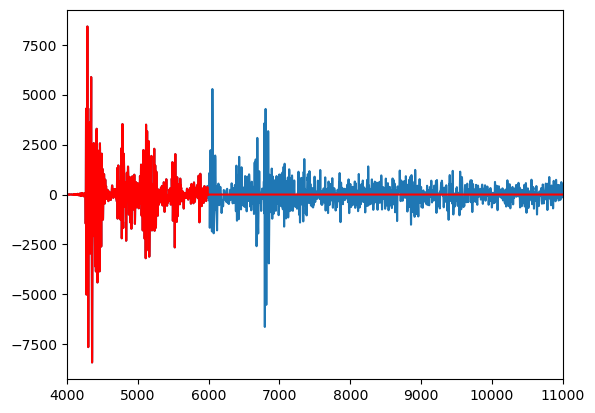

In [48]:
n=9
cross = sigmoidea(N,ncross[n,cr],2.0)
plt.plot(ir_binaural_all[n,:,1])
dir_wide = ir_binaural_all[n,:,1]*(1-cross)
plt.plot(dir_wide,'r')
plt.xlim(4000,11000)

(1000, 1000000.0)

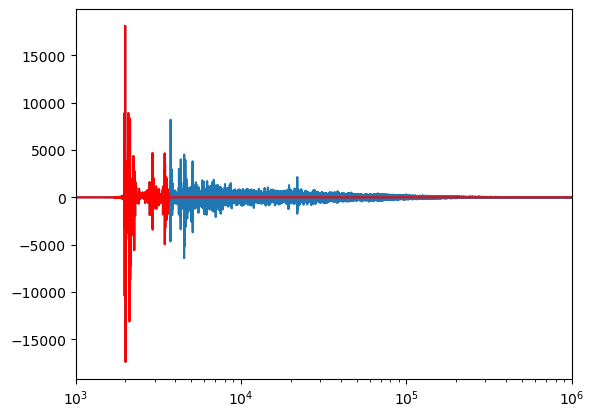

In [49]:
n=6
cross = sigmoidea(N,ncross[n,cr],2.0)
plt.semilogx(ir_binaural_all[n,:,1])
dir_wide = ir_binaural_all[n,:,1]*(1-cross)
plt.semilogx(dir_wide,'r')
plt.xlim(1000,1e6)

(4000, 1000000.0)

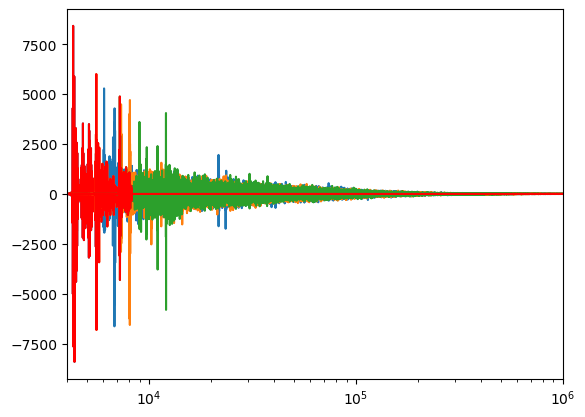

In [50]:
n=9
for m in range(3):
    cross = sigmoidea(N,ncross[n+m,cr],2.0)
    plt.semilogx(ir_binaural_all[n+m,:,1]+m*0.0025)
    dir_wide = ir_binaural_all[n+m,:,1]*(1-cross)
    plt.semilogx(dir_wide+m*0.0025,'r')
plt.xlim(4000,1e6)

In [51]:
# FILTROS
order = 1
fcut = 1000
ftype = 'butter'
lpf = signal.iirfilter(order, fcut, btype='lowpass',ftype=ftype,fs=fs,output="sos")
hpf = signal.iirfilter(order, fcut, btype='highpass',ftype=ftype,fs=fs,output="sos")

In [52]:
labels = ['Wide-Wide','Low-Low','Low-Wide','Wide-Low']

In [53]:
ir_binaural_widelow = np.zeros_like(ir_binaural_all)
ir_binaural_lowwide = np.zeros_like(ir_binaural_all)
ir_binaural_low = np.zeros_like(ir_binaural_all)
ncross = np.load(rpath + "drcross.npy")
ncross2 = ncross
ncross2[11,cr] -= 700
alpha = 2.5
beta = 0.38
for n in range(12):
  cross = sigmoidea(N,ncross2[n,cr],2.0)
  ir_binaural_low[n,:,0] = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,0])
  ir_binaural_low[n,:,1] = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,1])
  # left channel
  dir_low = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,0]*(1-cross))
  dir_wide = ir_binaural_all[n,:,0]*(1-cross)
  rev_wide = ir_binaural_all[n,:,0]*cross
  rev_low = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,0]*cross)
  ir_binaural_lowwide[n,:,0] = alpha*dir_low+rev_wide/alpha
  ir_binaural_widelow[n,:,0] = beta*dir_wide+rev_low/beta
  #right channel  
  dir_low = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,1]*(1-cross))
  dir_wide = ir_binaural_all[n,:,1]*(1-cross)
  rev_wide = ir_binaural_all[n,:,1]*cross
  rev_low = signal.sosfiltfilt(lpf,ir_binaural_all[n,:,1]*cross)
  ir_binaural_lowwide[n,:,1] = alpha*dir_low+rev_wide/alpha
  ir_binaural_widelow[n,:,1] = beta*dir_wide+rev_low/beta

In [54]:
# equalization
nmean = np.zeros((4,))
nmean[0] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_all[0,:,:]),axis=0)*dt))
nmean[1] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_low[0,:,:]),axis=0)*dt))
nmean[2] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_widelow[0,:,:]),axis=0)*dt))
nmean[3] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_lowwide[0,:,:]),axis=0)*dt))
nmean

array([1.        , 0.16189404, 0.45842845, 0.32618056])

In [55]:
ir_binaural_all /= nmean[0]
ir_binaural_low /= nmean[1]
ir_binaural_widelow /= nmean[2]
ir_binaural_lowwide /= nmean[3]

In [56]:
cols = ["#008C29", "#EF0000", "#DB9501","#444DAD"]

In [57]:
# equalization
nmean = np.zeros((4,))
nmean[0] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_all[0,:,:]),axis=0)*dt))
nmean[1] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_low[0,:,:]),axis=0)*dt))
nmean[2] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_widelow[0,:,:]),axis=0)*dt))
nmean[3] = np.sqrt(np.mean(np.mean(np.square(ir_binaural_lowwide[0,:,:]),axis=0)*dt))
nmean

array([1., 1., 1., 1.])

In [58]:
Ldir2 = np.zeros((12,4))
Lrev2 = np.zeros((12,4))
Ltot2 = np.zeros((12,4))
Lref = 0.1
for n in range(12):
  Ltot2[n,0], Ldir2[n,0], Lrev2[n,0] = lbinaural_dr(ir_binaural_all[n,:,:],ncross[n,cr],dt,2,Lref)
  Ltot2[n,1], Ldir2[n,1], Lrev2[n,1] = lbinaural_dr(ir_binaural_low[n,:,:],ncross2[n,cr],dt,2,Lref)
  Ltot2[n,2], Ldir2[n,2], Lrev2[n,2] = lbinaural_dr(ir_binaural_lowwide[n,:,:],ncross[n,cr],dt,2,Lref)
  Ltot2[n,3], Ldir2[n,3], Lrev2[n,3] = lbinaural_dr(ir_binaural_widelow[n,:,:],ncross2[n,cr],dt,2,Lref)

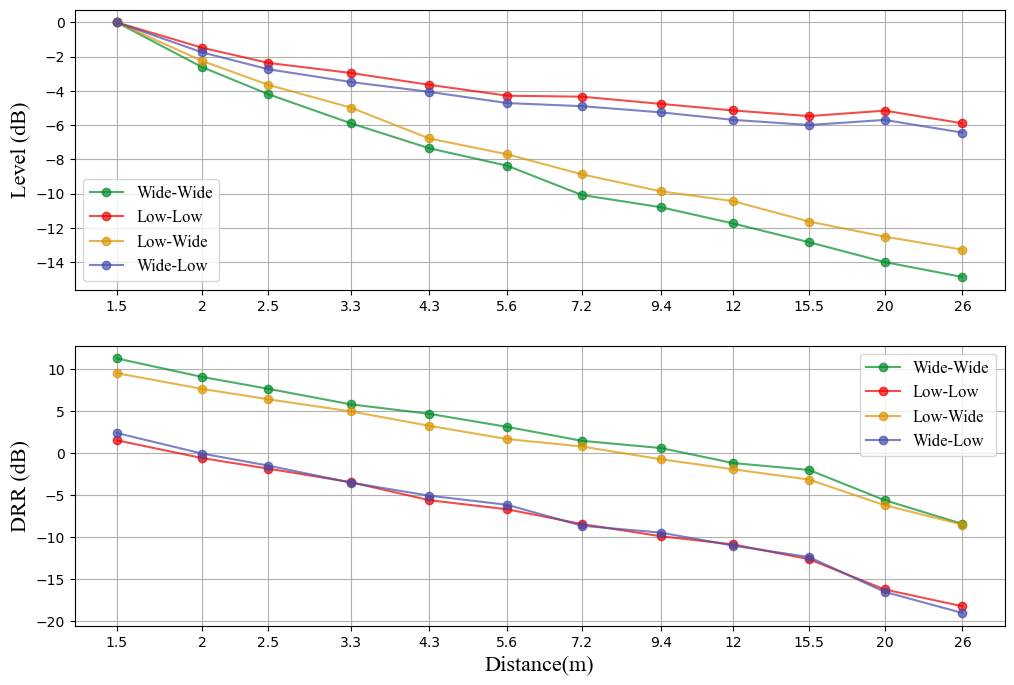

In [59]:
fig, axs = plt.subplots(2,1,figsize=(12,8))
font_properties = fm.FontProperties(family='Times New Roman', size=12)
for n in range(4):
    axs[0].semilogx(dist,Ltot2[:,n]-Ltot2[0,n],color=cols[n],marker="o",alpha=0.7,label=labels[n])
    axs[1].semilogx(dist,Ldir2[:,n]-Lrev2[:,n],marker="o",alpha=0.7,color=cols[n],label=labels[n])
for m in range(2):
    axs[m].set_xticks(dist,dists)
    axs[m].minorticks_off()
    axs[m].legend(prop=font_properties)
    axs[m].grid()
axs[1].set_xlabel('Distance(m)',fontname="Times New Roman", fontsize=16)    
axs[0].set_ylabel('Level (dB)',fontname="Times New Roman", fontsize=16)
axs[1].set_ylabel('DRR (dB)',fontname="Times New Roman", fontsize=16)
#axs[0].set_rasterized(True)
#axs[1].set_rasterized(True)
plt.savefig('Figure2.png', format='png')

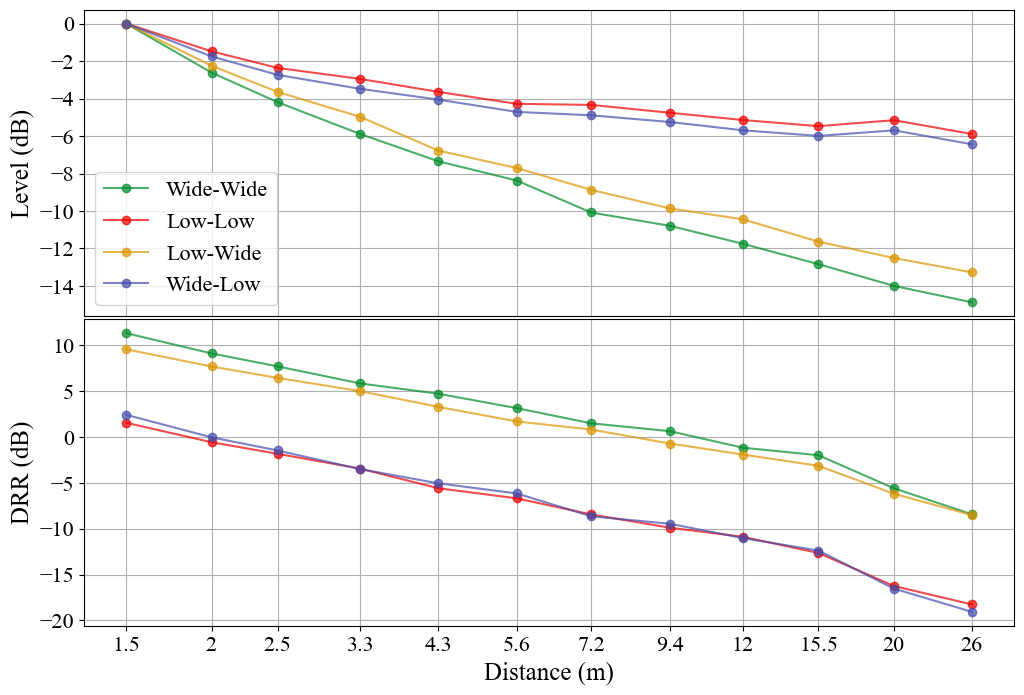

In [123]:
fig, axs = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={'hspace': 0.01}
)

font_properties = fm.FontProperties(
    family='Times New Roman',
    size=16
)

for n in range(4):
    axs[0].semilogx(
        dist,
        Ltot2[:, n] - Ltot2[0, n],
        color=cols[n],
        marker="o",
        alpha=0.7,
        label=labels[n]
    )

    axs[1].semilogx(
        dist,
        Ldir2[:, n] - Lrev2[:, n],
        marker="o",
        alpha=0.7,
        color=cols[n],
        label=labels[n]
    )

# Configure plots
for m in range(2):
    axs[m].set_xticks(dist, dists)
    axs[m].minorticks_off()
    axs[m].grid()

# Legend only on the upper plot
#axs[0].legend(prop=font_properties)
axs[0].legend(
    loc='lower left',
    prop=fm.FontProperties(
    family='Times New Roman',
    size=16
    ),
)

# Hide x tick labels on upper plot
axs[0].tick_params(
    axis='x',
    which='both',
    labelbottom=False,
    bottom=False
)

# Labels
axs[1].set_xlabel(
    'Distance (m)',
    fontname="Times New Roman",
    fontsize=18
)

axs[0].set_ylabel(
    'Level (dB)',
    fontname="Times New Roman",
    fontsize=18
)

axs[1].set_ylabel(
    'DRR (dB)',
    fontname="Times New Roman",
    fontsize=18
)

# Optional rasterization
# axs[0].set_rasterized(True)
# axs[1].set_rasterized(True)


for ax in axs:

    plt.setp(
        ax.get_xticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

    plt.setp(
        ax.get_yticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

plt.savefig(
    'Figure2.png',
    format='png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [69]:
[str(x) for  x in dist]

['1.5',
 '2.0',
 '2.5',
 '3.3',
 '4.3',
 '5.6',
 '7.2',
 '9.4',
 '12.0',
 '15.5',
 '20.0',
 '26.0']

In [ ]:
#np.savetxt("Sound_level.csv",Ltot2,fmt='%.5f',delimiter=",")
#np.savetxt("DRR.csv",Ldir2-Lrev2,fmt='%.5f',delimiter=",")

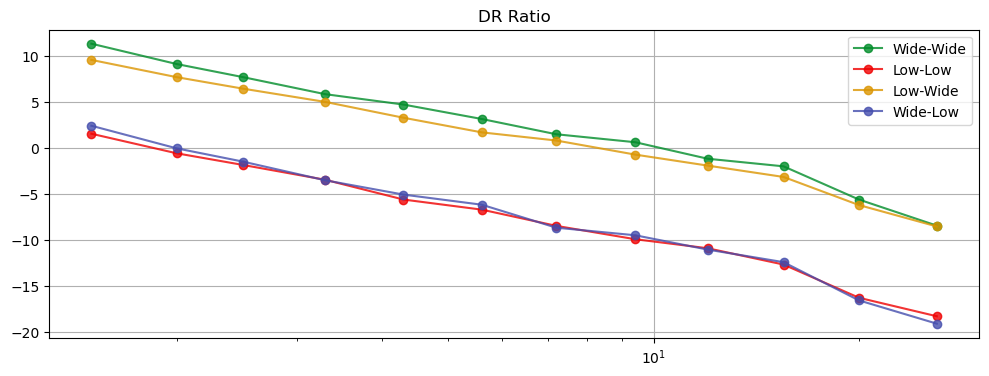

In [70]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.semilogx(dist,Ldir2[:,n]-Lrev2[:,n],marker="o",alpha=0.8,color=cols[n],label=labels[n])
ax.title.set_text('DR Ratio')
ax.legend()
ax.grid()

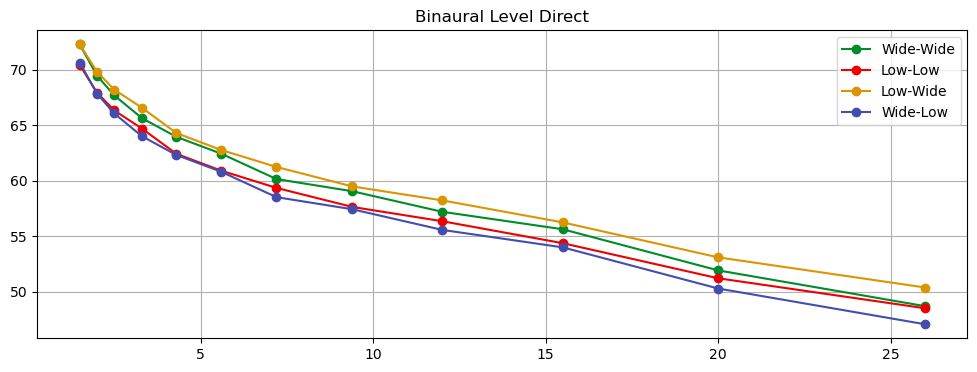

In [71]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.plot(dist,Ldir2[:,n],color=cols[n],marker="o",label=labels[n])
ax.title.set_text('Binaural Level Direct')
ax.legend()
ax.grid()

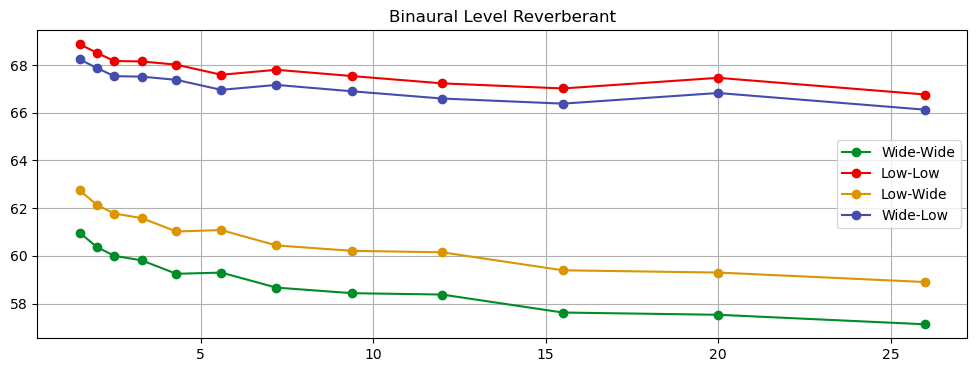

In [72]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.plot(dist,Lrev2[:,n],color=cols[n],marker="o",label=labels[n])
ax.title.set_text('Binaural Level Reverberant')
ax.legend()
ax.grid()

# Por tercio de Octava

Banco de filtros generado: 10 octavas,3 bandas/octava,desde 31.25 Hz,Almacenada en archivo fbank_third


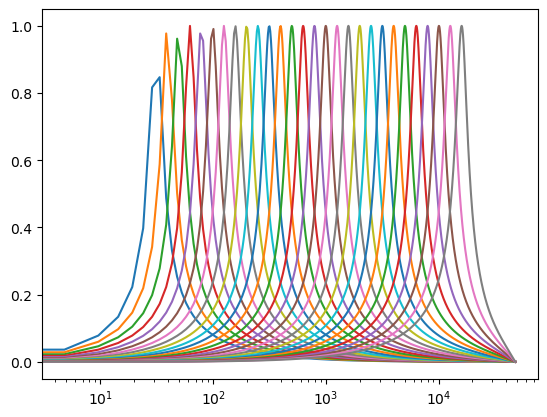

In [73]:
fb = make_filterbank(fmin=31.25,noct=10,bwoct=3,fs=fs,order=1,N=10000,bankname='fbank_third',show=True)

In [74]:
# ESTO LLEVA TIEMPO OJO
fbank = np.load('fbank_third.npz')
fc = fbank['fc']
sp_3rd = np.zeros((12,4,len(fc)))
sp_dir3rd = np.zeros((12,4,len(fc)))
sp_rev3rd = np.zeros((12,4,len(fc)))
for n in range(12):
    print(n)
    cross = sigmoidea(N,ncross[n,cr],2.0)
    data_filt = apply_bands(ir_binaural_all[n,:,:], bankname='fbank_third', fs=fs, norma=False)
    sp_3rd[n,0,:], sp_dir3rd[n,0,:], sp_rev3rd[n,0,:] = lbinaural_dr(data_filt,ncross[n,cr]-200,dt,2,Lref)
    data_filt = apply_bands(ir_binaural_widelow[n,:,:], bankname='fbank_third', fs=fs, norma=False)
    sp_3rd[n,3,:], sp_dir3rd[n,3,:], sp_rev3rd[n,3,:] = lbinaural_dr(data_filt,ncross2[n,cr]-200,dt,2,Lref)
    data_filt = apply_bands(ir_binaural_lowwide[n,:,:], bankname='fbank_third', fs=fs, norma=False)
    sp_3rd[n,2,:], sp_dir3rd[n,2,:], sp_rev3rd[n,2,:] = lbinaural_dr(data_filt,ncross[n,cr]-200,dt,2,Lref)
    data_filt = apply_bands(ir_binaural_low[n,:,:], bankname='fbank_third', fs=fs, norma=False)
    sp_3rd[n,1,:], sp_dir3rd[n,1,:], sp_rev3rd[n,1,:] = lbinaural_dr(data_filt,ncross2[n,cr]-200,dt,2,Lref)
    

0
1
2
3
4
5
6
7
8
9
10
11


In [75]:
wn = whitenoise(20.0,fadein=0.05, fadeout=0.05, fs=48000)

In [76]:
wn_filt = np.zeros_like(wn)
wn_filt[:,0] = signal.sosfiltfilt(lpf,wn[:,0])

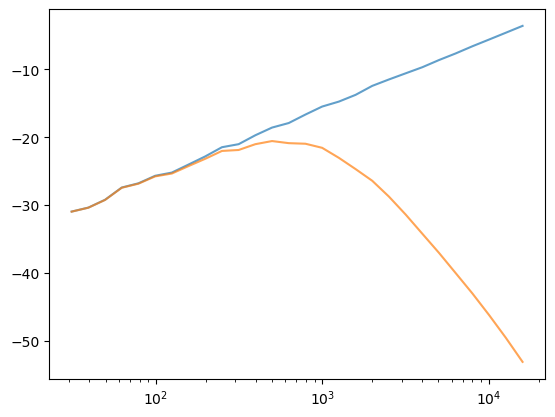

In [77]:
fwn = apply_bands(wn, bankname='fbank_third', fs=48000, norma=False)
sp_wn, _, _ = lbinaural_dr(np.concatenate([fwn, fwn],axis=2),1,1/48000,2,Lref)
fwnf = apply_bands(wn_filt, bankname='fbank_third', fs=48000, norma=False)
sp_wnf, _, _ = lbinaural_dr(np.concatenate([fwnf, fwnf],axis=2),1,1/48000,2,Lref)
plt.semilogx(fc,sp_wn,'-',alpha=0.7,label=None)
plt.semilogx(fc,sp_wnf,'-',alpha=0.7,label=None)

In [78]:
# correction 1
sp_dir3rd[:,1,:]-=3

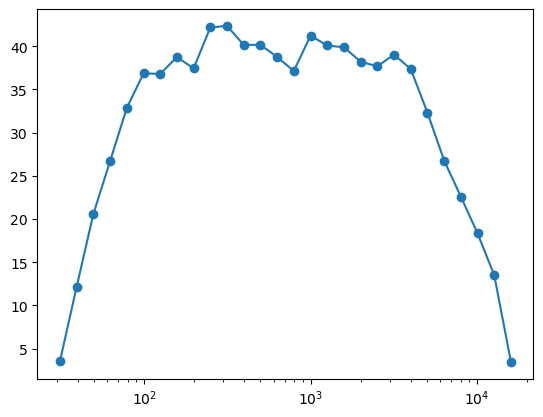

In [79]:
plt.semilogx(fc,sp_dir3rd[8,1,:],'-o')

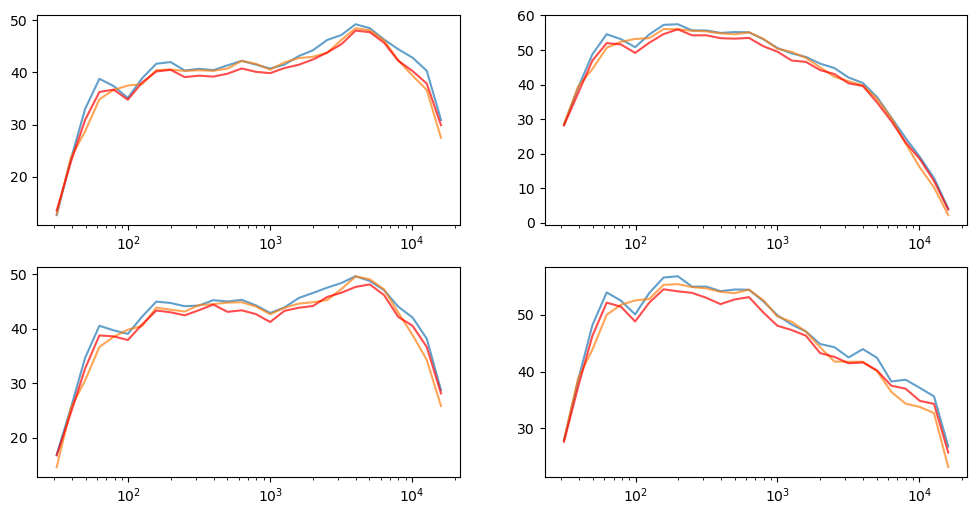

In [80]:
temp = (sp_3rd[10,:,:] + 0.3*sp_3rd[11,:,:] + 2*np.random.rand(4,28))/1.36
temp2 = (sp_dir3rd[10,:,:] + 0.3*sp_dir3rd[11,:,:] + 6*np.random.rand(4,28))/1.6
temp3 = (sp_rev3rd[10,:,:] + 2*np.random.rand(4,28))/1.05
fig, axs = plt.subplots(2,2,figsize=(12,6))
for n in range(4):
    (nx,ny) = [n//2, np.mod(n,2)]
    axs[nx,ny].semilogx(fc,sp_3rd[10:,n,:].T,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc,temp[n,:],'r-',alpha=0.7,label=None)

In [81]:
cmap = plt.cm.get_cmap('plasma')
num_colors =12
custom_colors = [cmap(i / (num_colors + 3)) for i in range(num_colors)]
mpl.rcParams['axes.prop_cycle'] = cycler(color=custom_colors)
adj = -65

C:\Users\Lucas\AppData\Local\Temp\ipykernel_14136\3336251244.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')


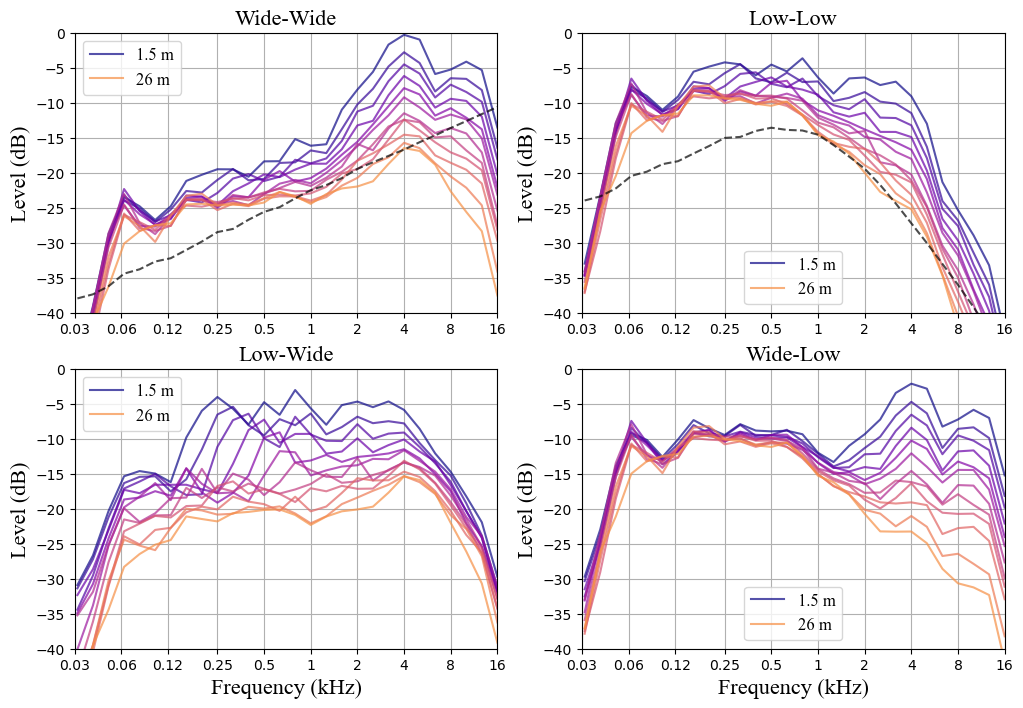

In [82]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
for n in range(4):
    (nx,ny) = [n//2, np.mod(n,2)]
    axs[nx,ny].semilogx(fc/1000,sp_3rd[:1,n,:].T+adj,'-',alpha=0.7,label='1.5 m')
    axs[nx,ny].semilogx(fc/1000,sp_3rd[1:11,n,:].T+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_3rd[11:,n,:].T+adj,'-',alpha=0.7,label='26 m')
    if n==0:
        axs[nx,ny].semilogx(fc/1000,sp_wn+58+adj,'k--',alpha=0.7,label=None)
    elif n==1:
        axs[nx,ny].semilogx(fc/1000,sp_wnf+72+adj,'k--',alpha=0.7,label=None)
    if nx>0:
        axs[nx,ny].set_xlabel("Frequency (kHz)",fontname="Times New Roman", fontsize=16);
    axs[nx,ny].set_ylabel("Level (dB)",fontname="Times New Roman", fontsize=16);
    #axs[nx,ny].semilogx(fc,temp[n,:]+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].set_title(labels[n],fontname="Times New Roman", fontsize=16)
    axs[nx,ny].set_xlim(0.03,16)
    axs[nx,ny].set_ylim(-40,0)
    axs[nx,ny].grid()
    axs[nx,ny].legend(prop=font_properties)
    axs[nx,ny].set_xticks([0.03,0.06,0.12,0.25,0.5,1,2,4,8,16],['0.03','0.06','0.12','0.25','0.5','1','2','4','8','16'])
    #axs[nx,ny].xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    axs[nx,ny].minorticks_off()
    #axs[nx,ny].set_rasterized(True)

plt.savefig('Figure3.png', format='png')

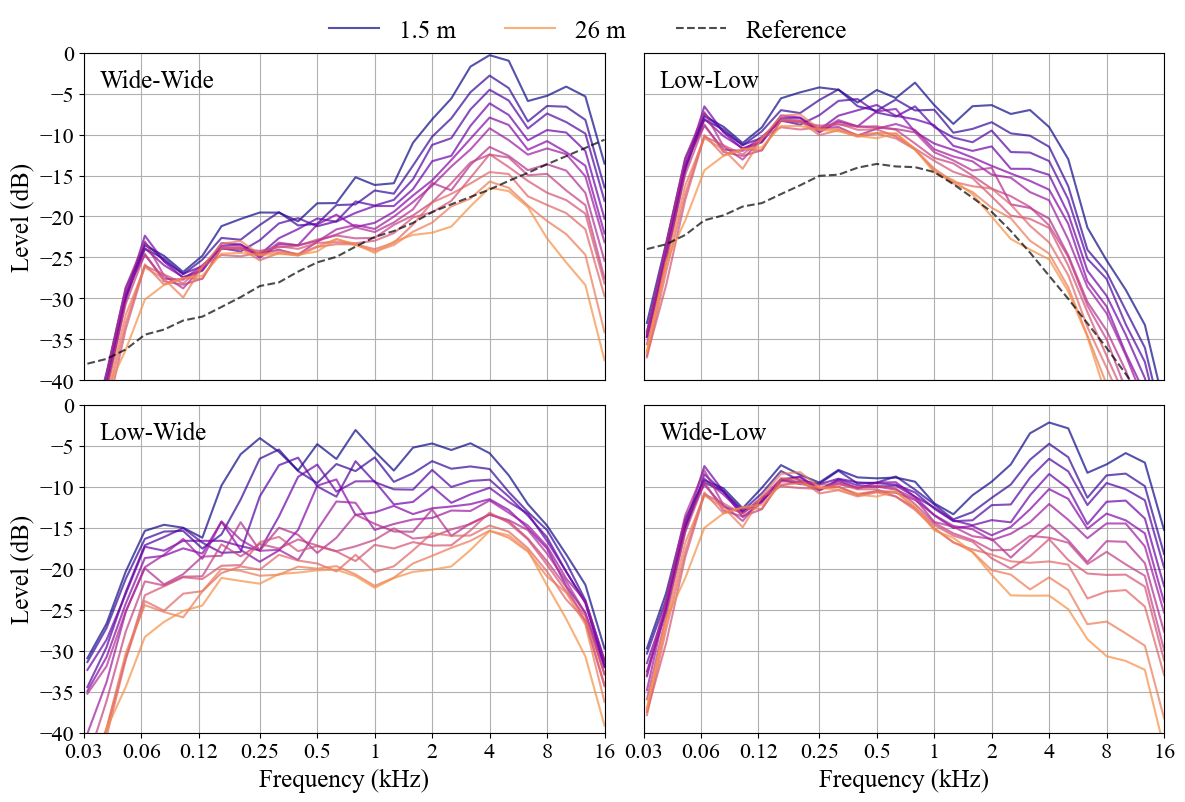

In [115]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={'wspace': 0.075, 'hspace': 0.075}
)

axs = axs.ravel()

for n in range(4):

    ax = axs[n]

    # 1.5 m
    ax.semilogx(
        fc / 1000,
        sp_3rd[:1, n, :].T + adj,
        '-',
        alpha=0.7,
        label='1.5 m'
    )

    # Intermediate distances
    ax.semilogx(
        fc / 1000,
        sp_3rd[1:11, n, :].T + adj,
        '-',
        alpha=0.7,
        label=None
    )

    # 26 m
    ax.semilogx(
        fc / 1000,
        sp_3rd[11:, n, :].T + adj,
        '-',
        alpha=0.7,
        label='26 m'
    )

    # Reference curves
    if n == 0:
        ax.semilogx(
            fc / 1000,
            sp_wn + 58 + adj,
            'k--',
            alpha=0.7,
            label='Reference'
        )

    elif n == 1:
        ax.semilogx(
            fc / 1000,
            sp_wnf + 72 + adj,
            'k--',
            alpha=0.7,
            label=None
        )

    # Limits
    ax.set_xlim(0.03, 16)
    ax.set_ylim(-40, 0)

    # Grid
    ax.grid()

    # X ticks
    ax.set_xticks(
        [0.03, 0.06, 0.12, 0.25, 0.5, 1, 2, 4, 8, 16],
        ['0.03', '0.06', '0.12', '0.25', '0.5', '1', '2', '4', '8', '16']
    )

    ax.minorticks_off()

    # Titles inside plots
    ax.text(
        0.03, 0.95,
        labels[n],
        transform=ax.transAxes,
        fontname="Times New Roman",
        fontsize=18,
        va='top',
        ha='left'
    )


# ---------------------------------------------------------
# AXIS LABELS
# ---------------------------------------------------------

# X label only on bottom plots
axs[2].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

axs[3].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

# Y label only on left plots
axs[0].set_ylabel(
    "Level (dB)",
    fontname="Times New Roman",
    fontsize=18
)

axs[2].set_ylabel(
    "Level (dB)",
    fontname="Times New Roman",
    fontsize=18
)


# ---------------------------------------------------------
# REMOVE INTERNAL TICK LABELS
# ---------------------------------------------------------

# Upper row: remove bottom x tick labels and tick marks
for ax in axs[:2]:
    ax.tick_params(
        axis='x',
        which='both',
        bottom=False,
        labelbottom=False
    )

# Right column: remove left y tick labels and tick marks
for ax in [axs[1], axs[3]]:
    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )


# ---------------------------------------------------------
# SHARED LEGEND
# ---------------------------------------------------------
handles, legend_labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    prop=fm.FontProperties(
        family='Times New Roman',
        size=18
    ),
    frameon=False
)


for ax in axs:

    plt.setp(
        ax.get_xticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

    plt.setp(
        ax.get_yticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

# ---------------------------------------------------------
# LAYOUT
# ---------------------------------------------------------

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.95,
    wspace=0,
    hspace=0
)


plt.savefig(
    'Figure3.png',
    format='png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

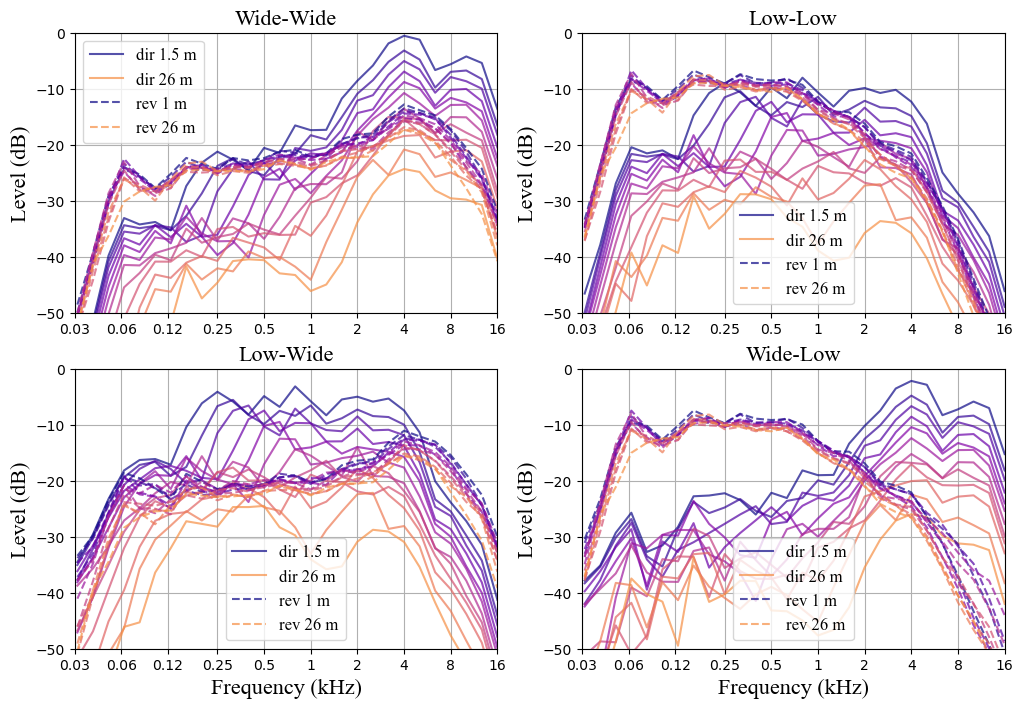

In [96]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
for n in range(4):
    (nx,ny) = [n//2, np.mod(n,2)]
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[:1,n,:].T+adj,'-',alpha=0.7,label='dir 1.5 m')
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[1:11,n,:].T+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[11:,n,:].T+adj,'-',alpha=0.7,label='dir 26 m')
    #axs[nx,ny].semilogx(fc,temp2[n,:]+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_rev3rd[:1,n,:].T+adj,'--',alpha=0.7,label='rev 1 m')
    axs[nx,ny].semilogx(fc/1000,sp_rev3rd[1:11,n,:].T+adj,'--',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_rev3rd[11:,n,:].T+adj,'--',alpha=0.7,label='rev 26 m')
    #axs[nx,ny].semilogx(fc,temp3[n,:]+adj,'--',alpha=0.7,label=None)
    
    if nx>0:
        axs[nx,ny].set_xlabel("Frequency (kHz)",fontname="Times New Roman", fontsize=16);
    axs[nx,ny].set_ylabel("Level (dB)",fontname="Times New Roman", fontsize=16);
    #axs[nx,ny].semilogx(fc,temp[n,:]+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].set_title(labels[n],fontname="Times New Roman", fontsize=16)
    axs[nx,ny].set_xlim(0.03,16)
    axs[nx,ny].set_ylim(-50,0)
    axs[nx,ny].grid()
    axs[nx,ny].legend(prop=font_properties)
    axs[nx,ny].set_xticks([0.03,0.06,0.12,0.25,0.5,1,2,4,8,16],['0.03','0.06','0.12','0.25','0.5','1','2','4','8','16'])
    #axs[nx,ny].xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    axs[nx,ny].minorticks_off()

plt.savefig('Figure5.png', format='png')    

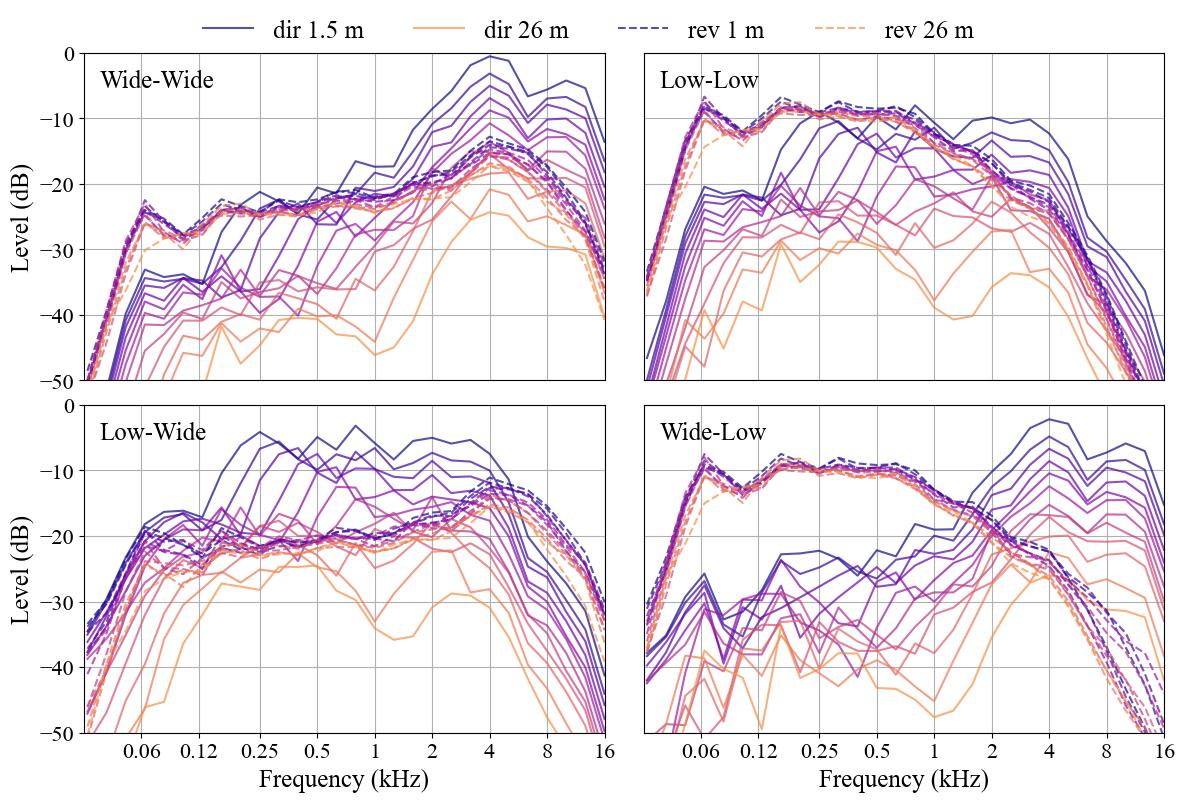

In [118]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={
        'wspace': 0.075,
        'hspace': 0.075
    }
)

# Flatten axes for easier indexing
axs = axs.ravel()

# X-axis ticks
xticks = [0.03, 0.06, 0.12, 0.25, 0.5, 1, 2, 4, 8, 16]
xticklabels = [
    '0.03', '0.06', '0.12', '0.25', '0.5',
    '1', '2', '4', '8', '16'
]

for n in range(4):

    ax = axs[n]

    # -------------------------------------------------
    # Direct sound
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[:1, n, :].T + adj,
        '-',
        alpha=0.7,
        label='dir 1.5 m'
    )

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[1:11, n, :].T + adj,
        '-',
        alpha=0.7,
        label=None
    )

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[11:, n, :].T + adj,
        '-',
        alpha=0.7,
        label='dir 26 m'
    )


    # -------------------------------------------------
    # Reverberant sound
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_rev3rd[:1, n, :].T + adj,
        '--',
        alpha=0.7,
        label='rev 1 m'
    )

    ax.semilogx(
        fc / 1000,
        sp_rev3rd[1:11, n, :].T + adj,
        '--',
        alpha=0.7,
        label=None
    )

    ax.semilogx(
        fc / 1000,
        sp_rev3rd[11:, n, :].T + adj,
        '--',
        alpha=0.7,
        label='rev 26 m'
    )


    # -------------------------------------------------
    # Axis limits
    # -------------------------------------------------

    ax.set_xlim(0.03, 16)
    ax.set_ylim(-50, 0)


    # -------------------------------------------------
    # Grid
    # -------------------------------------------------

    ax.grid()


    # -------------------------------------------------
    # X-axis ticks
    # -------------------------------------------------

    ax.set_xticks(
        xticks,
        xticklabels
    )

    ax.minorticks_off()


    # -------------------------------------------------
    # Title inside plot
    # -------------------------------------------------

    ax.text(
        0.03,
        0.95,
        labels[n],
        transform=ax.transAxes,
        fontname="Times New Roman",
        fontsize=18,
        va='top',
        ha='left'
    )


# =====================================================
# AXIS LABELS
# =====================================================

# X-axis label only on bottom row
axs[2].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

axs[3].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

# Y-axis label only on left column
axs[0].set_ylabel(
    "Level (dB)",
    fontname="Times New Roman",
    fontsize=18
)

axs[2].set_ylabel(
    "Level (dB)",
    fontname="Times New Roman",
    fontsize=18
)


# =====================================================
# REMOVE DUPLICATED INTERNAL AXIS LABELS
# =====================================================

# Upper row:
# Hide x-axis tick labels because bottom row shows them
for ax in axs[:2]:

    ax.tick_params(
        axis='x',
        which='both',
        bottom=False,
        labelbottom=False
    )


# Right column:
# Hide y-axis tick labels because left column shows them
for ax in [axs[1], axs[3]]:

    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )


# =====================================================
# FIX X-AXIS LABEL COLLISION AT INTERNAL BOUNDARY
# =====================================================

# Left column:
# Remove the rightmost tick (16)
for ax in [axs[0], axs[2]]:

    ax.set_xticks(
        xticks[:-1],
        xticklabels[:-1]
    )


# Right column:
# Remove the leftmost tick (0.03)
for ax in [axs[1], axs[3]]:

    ax.set_xticks(
        xticks[1:],
        xticklabels[1:]
    )


# =====================================================
# SHARED LEGEND
# =====================================================

# Get legend information from the first subplot
handles, legend_labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    prop=fm.FontProperties(
        family='Times New Roman',
        size=18
    ),
    frameon=False
)

for ax in axs:

    plt.setp(
        ax.get_xticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

    plt.setp(
        ax.get_yticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )



# =====================================================
# LAYOUT
# =====================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.95,
    wspace=0,
    hspace=0
)


# =====================================================
# SAVE
# =====================================================

plt.savefig(
    'Figure5.png',
    format='png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

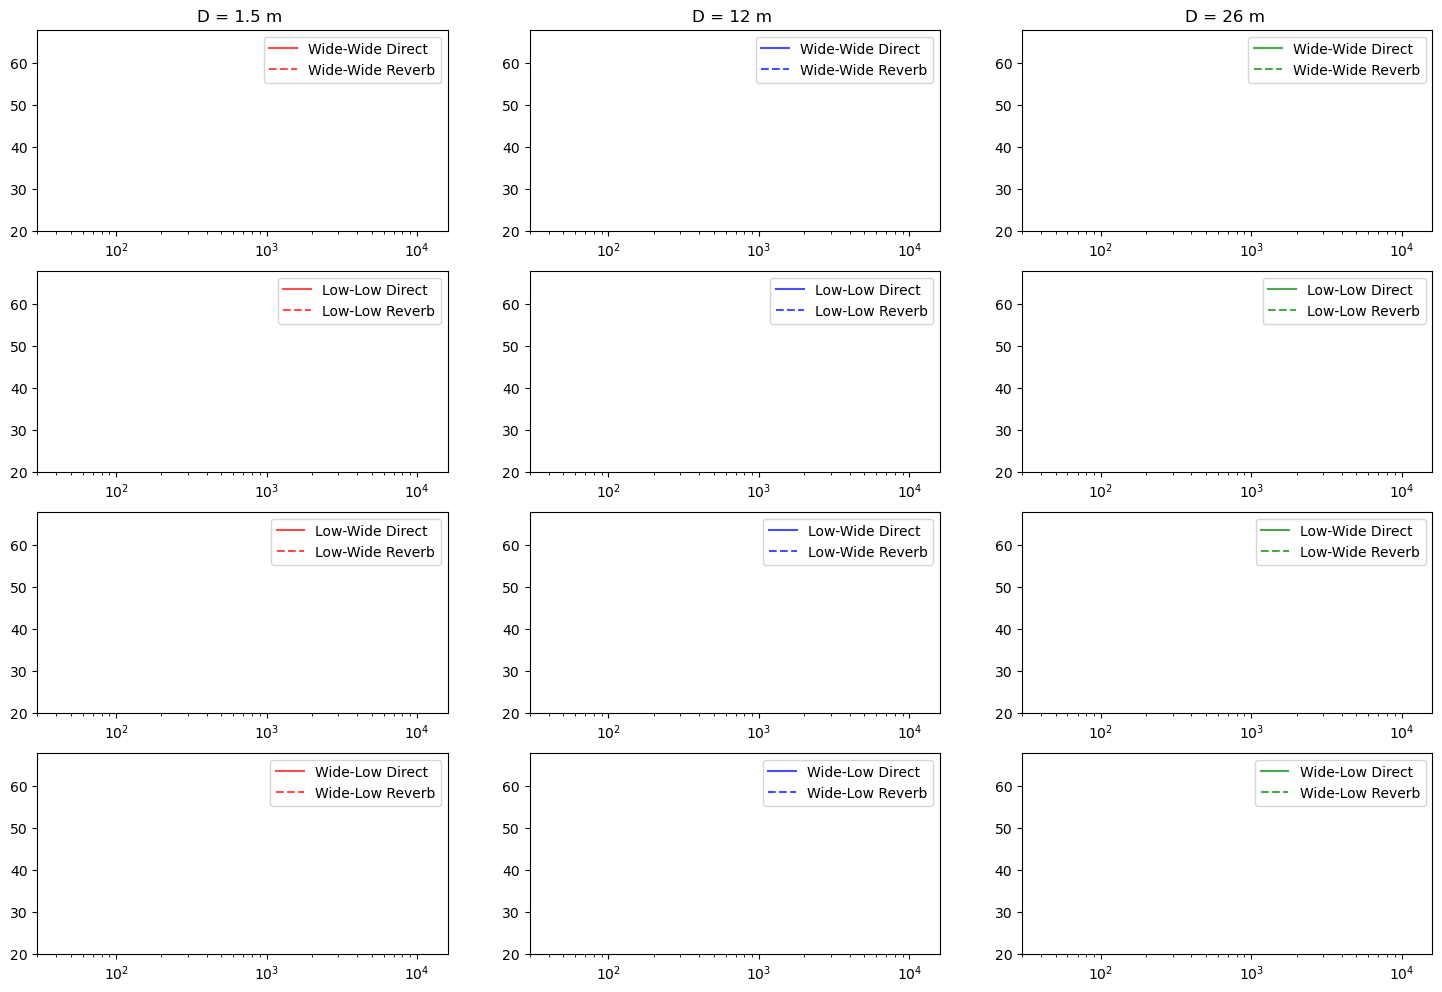

In [99]:
fig, axs = plt.subplots(4,3,figsize=(18,12))
for n in range(4):
    axs[n,0].semilogx(fc,sp_dir3rd[0,n,:].T+adj,'r-',alpha=0.7,label= labels[n] + " Direct")
    axs[n,1].semilogx(fc,sp_dir3rd[8,n,:].T+adj,'b-',alpha=0.7,label= labels[n] + " Direct")
    axs[n,2].semilogx(fc,sp_dir3rd[11,n,:].T+adj,'g-',alpha=0.7,label= labels[n] + " Direct")
    axs[n,0].semilogx(fc,sp_rev3rd[0,n,:].T+adj,'r--',alpha=0.7,label= labels[n] + " Reverb")
    axs[n,1].semilogx(fc,sp_rev3rd[8,n,:].T+adj,'b--',alpha=0.7,label=labels[n] + " Reverb")
    axs[n,2].semilogx(fc,sp_rev3rd[11,n,:].T+adj,'g--',alpha=0.7,label=labels[n] + " Reverb")
    axs[n,0].legend()
    axs[n,1].legend()
    axs[n,2].legend()
    axs[n,0].set_xlim(30,16000)
    axs[n,0].set_ylim(20,68)
    axs[n,1].set_xlim(30,16000)
    axs[n,1].set_ylim(20,68)
    axs[n,2].set_xlim(30,16000)
    axs[n,2].set_ylim(20,68)
    if n==4:
        axs[n,0].set_xlabel("Frequency");
        axs[n,1].set_xlabel("Frequency");
        axs[n,2].set_xlabel("Frequency");
    if n==0:
        axs[n,0].set_title("D = 1.5 m ")
        axs[n,1].set_title("D = 12 m ")
        axs[n,2].set_title("D = 26 m ")

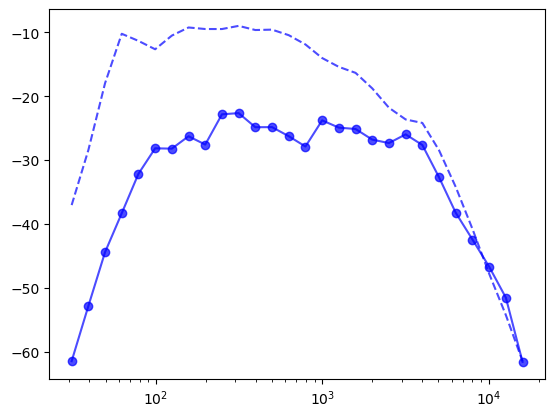

In [100]:
plt.semilogx(fc,sp_dir3rd[8,1,:].T+adj,'b-o',alpha=0.7,label= labels[n] + " Direct")
plt.semilogx(fc,sp_rev3rd[8,1,:].T+adj,'b--',alpha=0.7,label=labels[n] + " Reverb")

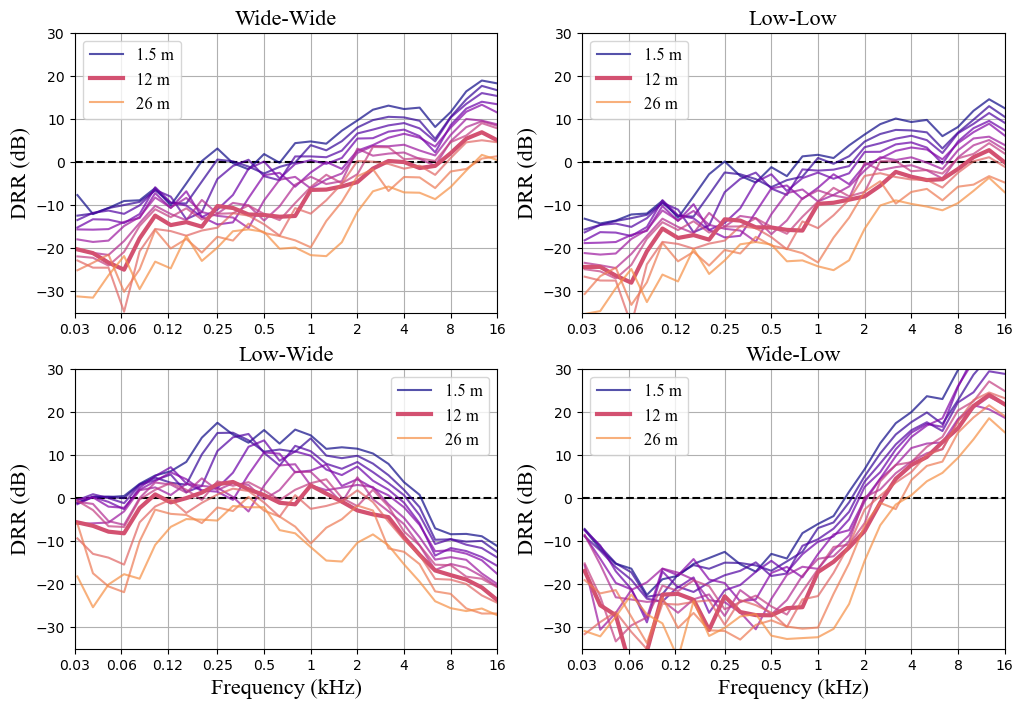

In [101]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
for n in range(4):
    (nx,ny) = [n//2, np.mod(n,2)]
    axs[nx,ny].semilogx([0.03,16],[0,0],'--k')
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[:1,n,:].T-sp_rev3rd[:1,n,:].T,'-',alpha=0.7,label='1.5 m')
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[1:8,n,:].T-sp_rev3rd[1:8,n,:].T,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[8:9,n,:].T-sp_rev3rd[8:9,n,:].T,'-',lw=3,alpha=1.0,label='12 m')
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[9:11,n,:].T-sp_rev3rd[9:11,n,:].T,'-',alpha=0.7,label=None)
    axs[nx,ny].semilogx(fc/1000,sp_dir3rd[11:,n,:].T-sp_rev3rd[11:,n,:].T,'-',alpha=0.7,label='26 m')
    if nx>0:
        axs[nx,ny].set_xlabel("Frequency (kHz)",fontname="Times New Roman", fontsize=16);
    axs[nx,ny].set_ylabel("DRR (dB)",fontname="Times New Roman", fontsize=16);
    #axs[nx,ny].semilogx(fc,temp[n,:]+adj,'-',alpha=0.7,label=None)
    axs[nx,ny].set_title(labels[n],fontname="Times New Roman", fontsize=16)
    axs[nx,ny].set_xlim(0.03,16)
    axs[nx,ny].set_ylim(-35,30)
    axs[nx,ny].grid()
    axs[nx,ny].legend(prop=font_properties)
    axs[nx,ny].set_xticks([0.03,0.06,0.12,0.25,0.5,1,2,4,8,16],['0.03','0.06','0.12','0.25','0.5','1','2','4','8','16'])
    #axs[nx,ny].xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    axs[nx,ny].minorticks_off()
    #axs[nx,ny].set_rasterized(True)

plt.savefig('Figure4.png', format='png')

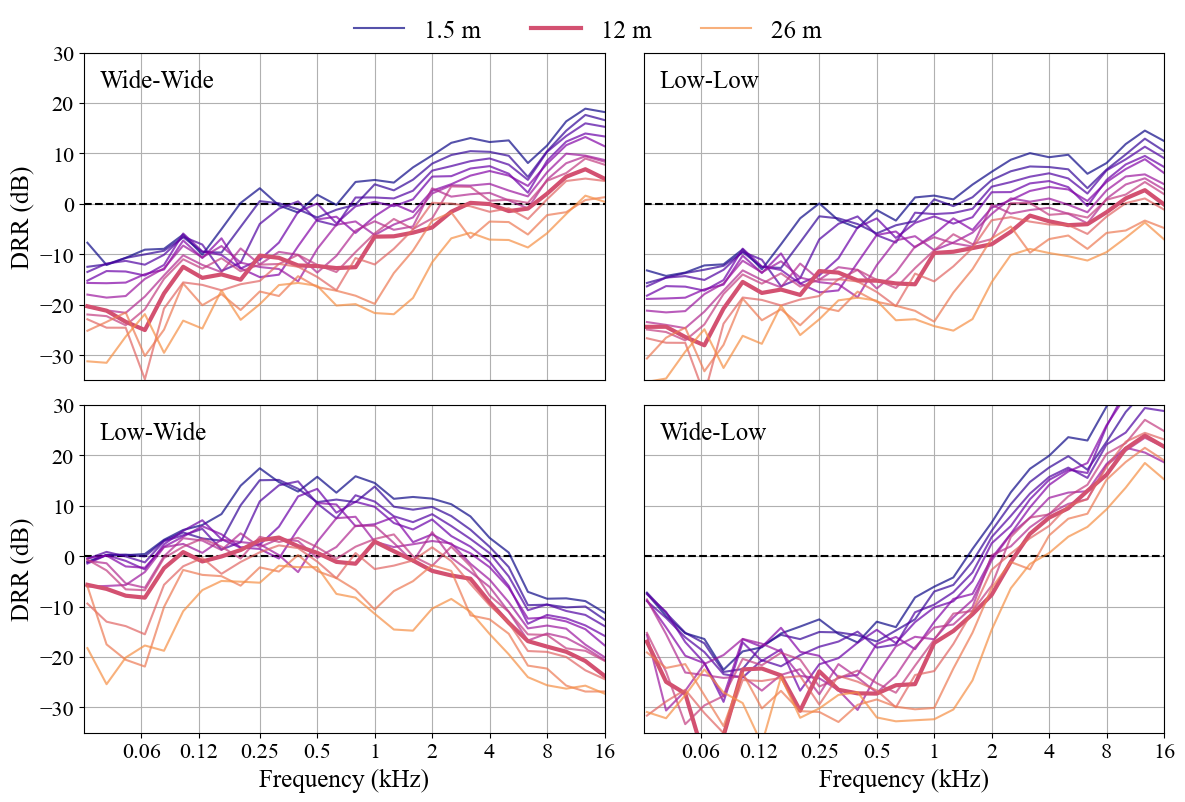

In [119]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={
        'wspace': 0.075,
        'hspace': 0.075
    }
)

# Flatten axes for easier indexing
axs = axs.ravel()

# X-axis ticks
xticks = [0.03, 0.06, 0.12, 0.25, 0.5, 1, 2, 4, 8, 16]
xticklabels = [
    '0.03', '0.06', '0.12', '0.25', '0.5',
    '1', '2', '4', '8', '16'
]


for n in range(4):

    ax = axs[n]

    # -------------------------------------------------
    # Reference line: DRR = 0 dB
    # -------------------------------------------------

    ax.semilogx(
        [0.03, 16],
        [0, 0],
        '--k'
    )


    # -------------------------------------------------
    # 1.5 m
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[:1, n, :].T - sp_rev3rd[:1, n, :].T,
        '-',
        alpha=0.7,
        label='1.5 m'
    )


    # -------------------------------------------------
    # Intermediate distances
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[1:8, n, :].T - sp_rev3rd[1:8, n, :].T,
        '-',
        alpha=0.7,
        label=None
    )


    # -------------------------------------------------
    # 12 m
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[8:9, n, :].T - sp_rev3rd[8:9, n, :].T,
        '-',
        lw=3,
        alpha=1.0,
        label='12 m'
    )


    # -------------------------------------------------
    # Intermediate distances
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[9:11, n, :].T - sp_rev3rd[9:11, n, :].T,
        '-',
        alpha=0.7,
        label=None
    )


    # -------------------------------------------------
    # 26 m
    # -------------------------------------------------

    ax.semilogx(
        fc / 1000,
        sp_dir3rd[11:, n, :].T - sp_rev3rd[11:, n, :].T,
        '-',
        alpha=0.7,
        label='26 m'
    )


    # -------------------------------------------------
    # Axis limits
    # -------------------------------------------------

    ax.set_xlim(0.03, 16)
    ax.set_ylim(-35, 30)


    # -------------------------------------------------
    # Grid
    # -------------------------------------------------

    ax.grid()


    # -------------------------------------------------
    # X-axis ticks
    # -------------------------------------------------

    ax.set_xticks(
        xticks,
        xticklabels
    )

    ax.minorticks_off()


    # -------------------------------------------------
    # Title inside plot
    # -------------------------------------------------

    ax.text(
        0.03,
        0.95,
        labels[n],
        transform=ax.transAxes,
        fontname="Times New Roman",
        fontsize=18,
        va='top',
        ha='left'
    )


# =====================================================
# AXIS LABELS
# =====================================================

# X-axis label only on bottom row
axs[2].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

axs[3].set_xlabel(
    "Frequency (kHz)",
    fontname="Times New Roman",
    fontsize=18
)

# Y-axis label only on left column
axs[0].set_ylabel(
    "DRR (dB)",
    fontname="Times New Roman",
    fontsize=18
)

axs[2].set_ylabel(
    "DRR (dB)",
    fontname="Times New Roman",
    fontsize=18
)


# =====================================================
# REMOVE DUPLICATED INTERNAL AXIS LABELS
# =====================================================

# Upper row:
# Hide x-axis tick labels because bottom row shows them
for ax in axs[:2]:

    ax.tick_params(
        axis='x',
        which='both',
        bottom=False,
        labelbottom=False
    )


# Right column:
# Hide y-axis tick labels because left column shows them
for ax in [axs[1], axs[3]]:

    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )


# =====================================================
# FIX X-AXIS LABEL COLLISION AT INTERNAL BOUNDARY
# =====================================================

# Left column:
# Remove the rightmost tick (16)
for ax in [axs[0], axs[2]]:

    ax.set_xticks(
        xticks[:-1],
        xticklabels[:-1]
    )


# Right column:
# Remove the leftmost tick (0.03)
for ax in [axs[1], axs[3]]:

    ax.set_xticks(
        xticks[1:],
        xticklabels[1:]
    )


# =====================================================
# SHARED LEGEND
# =====================================================

# Get legend information from first subplot
handles, legend_labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    prop=fm.FontProperties(
        family='Times New Roman',
        size=18
    ),
    frameon=False
)

for ax in axs:

    plt.setp(
        ax.get_xticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )

    plt.setp(
        ax.get_yticklabels(),
        fontname="Times New Roman",
        fontsize=16
    )


# =====================================================
# LAYOUT
# =====================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.95,
    wspace=0,
    hspace=0
)


# =====================================================
# SAVE
# =====================================================

plt.savefig(
    'Figure4.png',
    format='png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

# Otras Claves

In [ ]:
iacc_tot = np.zeros((12,4))
for n in range(12):
  iacf_tot, iacf_dir, iacf_rev = iacc_dr(ir_binaural_all[n,:,:],ncross[n,cr],fs)
  iacc_tot[n,0] = np.max(iacf_tot)
  iacf_tot, iacf_dir, iacf_rev = iacc_dr(ir_binaural_low[n,:,:],ncross[n,cr],fs)
  iacc_tot[n,1] = np.max(iacf_tot)
  iacf_tot, iacf_dir, iacf_rev = iacc_dr(ir_binaural_widelow[n,:,:],ncross[n,cr],fs)
  iacc_tot[n,2] = np.max(iacf_tot)
  iacf_tot, iacf_dir, iacf_rev = iacc_dr(ir_binaural_lowwide[n,:,:],ncross[n,cr],fs)
  iacc_tot[n,3] = np.max(iacf_tot)

In [ ]:
iacc_tot[11,1] += 0.11
iacc_tot[11,2] += 0.11

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.plot(dist,iacc_tot[:,n],color=colors[n],marker="o",label=labels[n])
ax.title.set_text('IACC')
ax.legend()
ax.grid()

In [ ]:
#np.savetxt("IACC.csv",iacc_tot,fmt='%.5f',delimiter=",")
#np.savetxt("Spectral_Centroid.csv",sc_tot,fmt='%.5f',delimiter=",")
#np.savetxt("Spectral_Variance.csv",sv_tot,fmt='%.5f',delimiter=",")

In [ ]:
sc_tot = np.zeros((12,4))
sc_dir = np.zeros((12,4))
sc_rev = np.zeros((12,4))
for n in range(12):
  sc_tot[n,0],sc_dir[n,0],sc_rev[n,0] = spectral_centroid_dr(ir_binaural_all[n,:,:],ncross[n,cr],fs=fs)
  sc_tot[n,1],sc_dir[n,1],sc_rev[n,1] = spectral_centroid_dr(ir_binaural_low[n,:,:],ncross[n,cr],fs=fs)
  sc_tot[n,2],sc_dir[n,2],sc_rev[n,2] = spectral_centroid_dr(ir_binaural_widelow[n,:,:],ncross[n,cr],fs=fs)
  sc_tot[n,3],sc_dir[n,3],sc_rev[n,3] = spectral_centroid_dr(ir_binaural_lowwide[n,:,:],ncross[n,cr],fs=fs)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.plot(dist,sc_tot[:,n],color=colors[n],marker="o",label=labels[n])
  ax.title.set_text('Spectral Centroid')
  ax.legend()
  ax.grid()

In [ ]:
sv_tot = np.zeros((12,4))
sv_dir = np.zeros((12,4))
sv_rev = np.zeros((12,4))
for n in range(12):
  sv_tot[n,0],sv_dir[n,0],sv_rev[n,0] = spectral_variance_dr(ir_binaural_all[n,:,:],ncross[n,cr],fs=fs)
  sv_tot[n,1],sv_dir[n,1],sv_rev[n,1] = spectral_variance_dr(ir_binaural_low[n,:,:],ncross[n,cr],fs=fs)
  sv_tot[n,2],sv_dir[n,2],sv_rev[n,2] = spectral_variance_dr(ir_binaural_widelow[n,:,:],ncross[n,cr],fs=fs)
  sv_tot[n,3],sv_dir[n,3],sv_rev[n,3] = spectral_variance_dr(ir_binaural_lowwide[n,:,:],ncross[n,cr],fs=fs)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
for n in range(4):
  ax.plot(dist,sv_tot[:,n],color=colors[n],marker="o",label=labels[n])
  ax.title.set_text('Spectral Variance')
  ax.legend()
  ax.grid()